# Прогнозирование стоимости жилой недвижимости

## Цель проекта
Разработать ML-модель для прогнозирования стоимости жилого объекта по данным объявления. 
Модель должна ускорить первичную оценку предложений и помочь риелторам быстрее находить потенциально выгодные сделки.

## Тип задачи
Задача обучения с учителем — регрессия. Целевая переменная будет извлечена из поля `target` и преобразована в числовую цену продажи.

In [97]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

df = pd.read_csv('data.csv')

print('Размер:', df.shape)
display(df.head(3))

Размер: (377185, 18)


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"


In [98]:
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique': df.nunique(dropna=True)
}).sort_values('missing_pct', ascending=False)

display(audit)

print('Полных дубликатов:', df.duplicated().sum())

,dtype,missing,missing_pct,unique
private pool,object,373004,98.89,1
mls-id,object,352243,93.39,24907
PrivatePool,object,336874,89.31,2
fireplace,object,274071,72.66,1652
stories,object,150716,39.96,347
baths,object,106338,28.19,229
beds,object,91282,24.20,1184
MlsId,object,66880,17.73,232944
sqft,object,40577,10.76,25405
status,object,39918,10.58,159


Полных дубликатов: 50


## Первичная оценка данных

Датасет содержит 377 185 объявлений и 18 исходных признаков. 
Перед обучением модели необходимо оценить пропуски, типы данных, уникальность значений и наличие дубликатов. 
Поля с текстовыми форматами (`target`, `sqft`, `beds`, `baths`, `homeFacts`) потребуют отдельного преобразования в модельные признаки.

In [99]:
df = df.drop_duplicates().copy()

print('Размер после удаления дубликатов:', df.shape)

Размер после удаления дубликатов: (377135, 18)


In [100]:
target_text = df['target'].fillna('').astype(str).str.strip().str.lower()

print('Пропусков target:', df['target'].isna().sum())
print('Объявлений с /mo:', target_text.str.contains(r'/mo', regex=True).sum())

print('\nПримеры target:')
print(df['target'].dropna().sample(20, random_state=RANDOM_STATE).to_list())

print('\nПримеры статусов аренды:')
display(
    df.loc[
        df['status'].fillna('').astype(str).str.lower().str.contains('rent'),
        ['status', 'target']
    ].head(10)
)

Пропусков target: 2480
Объявлений с /mo: 398

Примеры target:
['$69,500', '$519,000', '$325,000', '$302,990', '$829,000', '$749,888', '$409,999', '$217,580', '$229,000', '$299,000', '$979,000', '$485,000', '$110,000', '$4,500', '$286,000', '$469,500', '9,995,000', '$899,000', '365,000', '$895,995+']

Примеры статусов аренды:


,status,target
547,for rent,"$5,500/mo"
609,for rent,"$10,500/mo"
2075,for rent,"$6,390/mo"
3025,for rent,"$1,200/mo"
3645,for rent,"$3,600/mo"
4613,for rent,"$5,500/mo"
5515,for rent,"$1,200/mo"
5873,Apartment for rent,"$1,250"
6837,for rent,"$1,200/mo"
8167,for rent,"$3,250/mo"


In [101]:
status_text = df['status'].fillna('').astype(str).str.strip().str.lower()
target_text = df['target'].fillna('').astype(str).str.strip().str.lower()

is_rent = (
    status_text.str.contains(r'\brent\b', regex=True)
    | target_text.str.contains(r'/mo\b', regex=True)
)

df['price'] = pd.to_numeric(
    df['target']
      .astype(str)
      .str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

sales_df = df.loc[
    (~is_rent)
    & df['price'].notna()
    & (df['price'] >= 1_000)
].copy()

print('Всего после удаления дублей:', len(df))
print('Исключено как аренда:', is_rent.sum())
print('Без распознанной цены:', df['price'].isna().sum())
print('Выборка для продажи:', len(sales_df))

display(sales_df['price'].describe(percentiles=[0.01, 0.5, 0.99]))

Всего после удаления дублей: 377135
Исключено как аренда: 412
Без распознанной цены: 2480
Выборка для продажи: 374167


count    3.741670e+05
mean     6.455644e+05
std      1.842441e+06
min      1.000000e+03
1%       7.500000e+03
50%      3.200000e+05
99%      5.995000e+06
max      1.950000e+08
Name: price, dtype: float64

### Очистка целевой переменной

Целевая переменная `target` содержит стоимость объектов в текстовом формате. 
В датасете присутствуют объявления об аренде: часть определяется по `/mo` в цене, часть — только по статусу `for rent`.

Для задачи прогнозирования стоимости продажи из выборки исключаются объявления, если:
- статус содержит `rent`;
- цена содержит `/mo`;
- цена отсутствует или не преобразуется в число;
- цена меньше 1 000 долларов.

Очищенная целевая переменная сохраняется в колонке `price`.

In [102]:
display(
    sales_df[
        ['price', 'propertyType', 'city', 'state', 'zipcode', 'sqft', 'beds', 'baths', 'status']
    ]
    .sort_values('price')
    .head(20)
)

display(
    sales_df[
        ['price', 'propertyType', 'city', 'state', 'zipcode', 'sqft', 'beds', 'baths', 'status']
    ]
    .sort_values('price', ascending=False)
    .head(20)
)

,price,propertyType,city,state,zipcode,sqft,beds,baths,status
308660,1000.0,single-family home,Detroit,MI,48238,"1,848 sqft",4 Beds,2 Baths,foreclosure
221366,1000.0,single-family home,Detroit,MI,48204,721 sqft,3 Beds,NaN,foreclosure
135975,1000.0,Single Family,Detroit,MI,48205,"1,376 sqft",3,1.0,NaN
29572,1000.0,single-family home,Detroit,MI,48213,836 sqft,3 Beds,NaN,foreclosure
69965,1000.0,single-family home,Detroit,MI,48238,"1,902 sqft",3 Beds,NaN,foreclosure
97173,1000.0,single-family home,Detroit,MI,48238,800 sqft,3 Beds,NaN,foreclosure
125175,1000.0,single-family home,Detroit,MI,48234,771 sqft,3 Beds,NaN,foreclosure
76262,1000.0,single-family home,Detroit,MI,48234,900 sqft,3 Beds,NaN,foreclosure
167170,1000.0,single-family home,Detroit,MI,48213,"1,920 sqft",4 Beds,2 Baths,foreclosure
156779,1000.0,single-family home,Detroit,MI,48204,"2,600 sqft",6 Beds,2 Baths,foreclosure


,price,propertyType,city,state,zipcode,sqft,beds,baths,status
132425,195000000.0,Single Family,Los Angeles,CA,90077,--,11,18.0,For sale
143528,165000000.0,single-family home,Beverly Hills,CA,90210,"28,660 sqft",20 Beds,23 Baths,for sale
285993,165000000.0,Single Family,Beverly Hills,CA,90210,"28,660",20,23.0,For sale
110083,150000000.0,single-family home,Los Angeles,CA,90077,NaN,NaN,NaN,for sale
178931,129000000.0,Single Family,Beverly Hills,CA,90210,"43,000",12,23.0,For sale
119862,115000000.0,Single Family,Los Angeles,CA,90077,"12,201",9,10.0,For sale
294206,115000000.0,single-family home,Los Angeles,CA,90077,"12,201 sqft",9 Beds,10 Baths,for sale
354264,110000000.0,lot/land,Beverly Hills,CA,90210,741 sqft,NaN,NaN,for sale
54164,110000000.0,single-family home,Beverly Hills,CA,90210,"38,000 sqft",12 Beds,24 Baths,for sale
151594,98000000.0,Condo,New York,NY,10016,"19,815",11,14,For sale


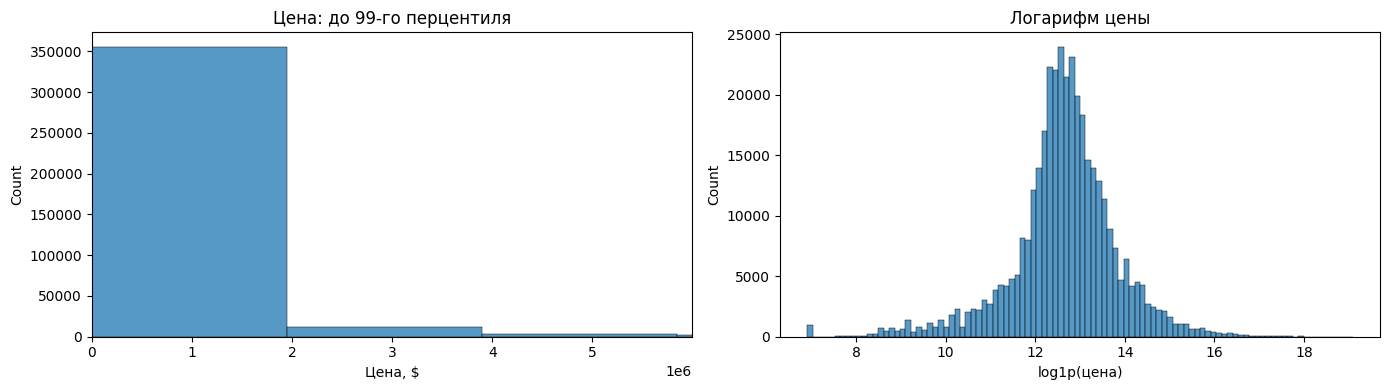

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_df['log_price'] = np.log1p(sales_df['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(sales_df['price'], bins=100, ax=axes[0])
axes[0].set_xlim(0, sales_df['price'].quantile(0.99))
axes[0].set_title('Цена: до 99-го перцентиля')
axes[0].set_xlabel('Цена, $')

sns.histplot(sales_df['log_price'], bins=100, ax=axes[1])
axes[1].set_title('Логарифм цены')
axes[1].set_xlabel('log1p(цена)')

plt.tight_layout()
plt.show()

### Распределение целевой переменной

Распределение цены имеет выраженную правостороннюю асимметрию: небольшая доля дорогих объектов существенно превышает типичный уровень цен. 
Экстремальные значения соответствуют реальным сегментам рынка — например, объектам в Beverly Hills, Los Angeles и New York — поэтому они сохранены.

Для обучения будет дополнительно рассмотрена трансформация `log1p(price)`. Она уменьшает влияние длинного правого хвоста и может повысить устойчивость модели. 

In [104]:
import re

def extract_number(value):
    if pd.isna(value):
        return np.nan
    
    match = re.search(r'\d+(?:\.\d+)?', str(value).replace(',', ''))
    return float(match.group()) if match else np.nan

for col in ['sqft', 'beds', 'baths', 'stories']:
    sales_df[f'{col}_num'] = sales_df[col].apply(extract_number)

numeric_report = pd.DataFrame({
    'missing_pct': (
        sales_df[['sqft_num', 'beds_num', 'baths_num', 'stories_num']]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),
    'min': sales_df[['sqft_num', 'beds_num', 'baths_num', 'stories_num']].min(),
    'median': sales_df[['sqft_num', 'beds_num', 'baths_num', 'stories_num']].median(),
    'max': sales_df[['sqft_num', 'beds_num', 'baths_num', 'stories_num']].max()
})

display(numeric_report)

,missing_pct,min,median,max
sqft_num,10.92,0.0,1800.0,795979430.0
beds_num,28.90,0.0,3.0,708248.0
baths_num,28.51,0.0,2.5,7500.0
stories_num,43.12,0.0,2.0,1120.0


In [105]:
valid_ranges = {
    'sqft_num': (100, 100_000),
    'beds_num': (1, 30),
    'baths_num': (0.5, 30),
    'stories_num': (1, 10)
}

for col, (low, high) in valid_ranges.items():
    invalid = sales_df[col].notna() & ~sales_df[col].between(low, high)
    print(f'{col}: некорректных значений — {invalid.sum()}')
    sales_df.loc[invalid, col] = np.nan

numeric_report_clean = pd.DataFrame({
    'missing_pct': (
        sales_df[['sqft_num', 'beds_num', 'baths_num', 'stories_num']]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),
    'min': sales_df[['sqft_num', 'beds_num', 'baths_num', 'stories_num']].min(),
    'median': sales_df[['sqft_num', 'beds_num', 'baths_num', 'stories_num']].median(),
    'max': sales_df[['sqft_num', 'beds_num', 'baths_num', 'stories_num']].max()
})

display(numeric_report_clean)

sqft_num: некорректных значений — 12691
beds_num: некорректных значений — 3664
baths_num: некорректных значений — 18547
stories_num: некорректных значений — 13273


,missing_pct,min,median,max
sqft_num,14.31,100.0,1839.0,100000.0
beds_num,29.88,1.0,3.0,30.0
baths_num,33.47,0.5,2.5,30.0
stories_num,46.67,1.0,2.0,10.0


In [106]:
for col in ['sqft_num', 'beds_num', 'baths_num', 'stories_num']:
    print(f'\n{col}')
    display(
        sales_df.loc[
            sales_df[col].notna(),
            [col, 'price', 'propertyType', 'city', 'state']
        ].sort_values(col).head(5)
    )
    display(
        sales_df.loc[
            sales_df[col].notna(),
            [col, 'price', 'propertyType', 'city', 'state']
        ].sort_values(col, ascending=False).head(5)
    )


sqft_num


,sqft_num,price,propertyType,city,state
182169,100.0,401369.0,Single Family,Miami,FL
162864,100.0,20000.0,Single Family Home,Alexandria,VA
246720,100.0,323127.0,Single Family,Miami Gardens,FL
221610,100.0,17490000.0,Single Family Home,Beverly Hills,CA
275184,100.0,259732.0,Single Family,North Miami Beach,FL


,sqft_num,price,propertyType,city,state
173711,100000.0,410000.0,coop,Brooklyn,NY
63514,99999.0,1600000.0,Multi-Family Home,Madison,TN
350352,99999.0,1600000.0,lot/land,Madison,TN
331200,99876.0,660000.0,coop,Elmhurst,NY
269404,99876.0,335000.0,coop,Elmhurst,NY



beds_num


,beds_num,price,propertyType,city,state
81249,1.0,475000.0,Condo,Miami,FL
80515,1.0,325000.0,Condo,Miami,FL
81188,1.0,235000.0,Condo,Miami,FL
102,1.0,259900.0,Condo,Miami,FL
330029,1.0,195500.0,Single Family Home,Circleville,OH


...

,baths_num,price,propertyType,city,state
125410,0.50,159000.0,lot/land,Panama City Beach,FL
129480,0.75,725000.0,single-family home,Seattle,WA
237230,0.75,394900.0,condo,Des Moines,WA
27983,1.00,233693.0,Single Family,Saint Petersburg,FL
28048,1.00,117000.0,Single Family Home,Parma,OH


,baths_num,price,propertyType,city,state
167137,30.0,3750000.0,townhouse,Fort Lauderdale,FL
242978,30.0,3495000.0,multi-family,Van Nuys,CA
338383,30.0,4500000.0,Multi-Family Home,Los Angeles,CA
231100,30.0,138000.0,Multi-Family Home,Marshall,MI
246995,30.0,3750000.0,Townhouse,Dania Beach,FL



stories_num


,stories_num,price,propertyType,city,state
13,1.0,499900.0,Single Family,Eugene,OR
377133,1.0,1090000.0,single-family home,Los Angeles,CA
377129,1.0,382990.0,Single Family Home,Englewood,FL
377125,1.0,399000.0,single-family home,Jacksonville,FL
377114,1.0,935000.0,single-family home,Staten Island,NY


,stories_num,price,propertyType,city,state
350144,10.0,310000.0,Condominium (Single Level),Seattle,WA
365917,10.0,569000.0,coop,New York,NY
240767,10.0,1707750.0,condo,Denver,CO
366848,10.0,530000.0,coop,Forest Hills,NY
141422,10.0,275000.0,Cooperative,New York,NY


In [107]:
property_type = (
    sales_df['propertyType']
    .fillna('missing')
    .astype(str)
    .str.strip()
    .str.lower()
)

print('Уникальных типов:', property_type.nunique())

display(property_type.value_counts().head(30))

Уникальных типов: 1272


propertyType
single-family home               91150
single family                    61884
condo                            42358
missing                          34538
single family home               31724
lot/land                         20467
townhouse                        18297
land                             10928
multi-family                      7762
condo/townhome/row home/co-op     7701
traditional                       5912
coop                              3264
multi family                      2768
high rise                         1823
ranch                             1781
detached, one story               1614
mobile/manufactured               1613
single detached, traditional      1581
contemporary                      1556
multi-family home                 1501
1 story                           1235
colonial                          1204
mobile / manufactured             1056
contemporary/modern               1000
2 stories                          911
mfd/mobile h

In [108]:
def group_property_type(value):
    text = str(value).strip().lower()

    if value == 'missing' or text in {'', 'nan', 'none'}:
        return 'missing'
    if 'land' in text or 'lot' in text:
        return 'land'
    if 'condo' in text or 'coop' in text or 'co-op' in text:
        return 'condo_coop'
    if 'town' in text or 'row home' in text:
        return 'townhouse'
    if 'multi' in text or 'duplex' in text or 'triplex' in text or 'fourplex' in text:
        return 'multi_family'
    if 'mobile' in text or 'manufactured' in text:
        return 'mobile_manufactured'
    if 'apartment' in text:
        return 'apartment'
    if (
        'single' in text
        or 'detached' in text
        or 'ranch' in text
        or 'colonial' in text
        or 'traditional' in text
        or 'contemporary' in text
        or 'one story' in text
        or 'two story' in text
    ):
        return 'single_family'
    
    return 'other'


sales_df['property_group'] = property_type.apply(group_property_type)

property_summary = (
    sales_df.groupby('property_group')['price']
    .agg(count='size', median_price='median', mean_price='mean')
    .sort_values('count', ascending=False)
)

property_summary['share_pct'] = (
    property_summary['count'] / len(sales_df) * 100
).round(2)

display(property_summary)

,count,median_price,mean_price,share_pct
property_group,,,,
single_family,206426,334990.0,609662.159554,55.17
condo_coop,55142,369900.0,816657.679573,14.74
missing,34662,310000.0,860066.595407,9.26
land,31465,73600.0,316754.857079,8.41
townhouse,18480,319994.0,576174.586472,4.94
multi_family,12549,599000.0,953159.750339,3.35
other,11074,349000.0,637108.126422,2.96
mobile_manufactured,3560,99500.0,125224.073876,0.95
apartment,809,550000.0,962028.862794,0.22


In [109]:
sales_df = sales_df.loc[
    sales_df['property_group'] != 'land'
].copy()

print('Размер после исключения land:', sales_df.shape)
print('Исключено объектов land:', (property_type == 'land').sum())

Размер после исключения land: (342702, 25)
Исключено объектов land: 10928


### Тип недвижимости

Исходный признак `propertyType` содержит 1 272 варианта, включая синонимы, архитектурные стили и разный регистр. 
Он был агрегирован в девять устойчивых групп.

Объекты `land` и `lot/land` составляют 8.41% выборки и имеют медианную цену 73 600 долларов, что существенно отличается от жилых объектов. 
Поскольку цель проекта — прогнозирование стоимости домов, земельные участки исключены из модельной выборки.

In [110]:
geo_report = pd.DataFrame({
    'missing': sales_df[['state', 'city', 'zipcode']].isna().sum(),
    'unique': sales_df[['state', 'city', 'zipcode']].nunique()
})

display(geo_report)

print('\nТоп-10 штатов:')
display(sales_df['state'].value_counts().head(10))

print('\nТоп-10 городов:')
display(sales_df['city'].value_counts().head(10))

,missing,unique
state,0,38
city,9,1908
zipcode,0,4469



Топ-10 штатов:


state
FL    101997
TX     77916
NY     23866
CA     22151
NC     18886
TN     15832
WA     12526
OH     11495
IL      8179
NV      7642
Name: count, dtype: int64


Топ-10 городов:


city
Houston         23278
Miami           15244
San Antonio     15018
Jacksonville     9467
Dallas           8399
Brooklyn         7183
New York         6902
Chicago          6327
Charlotte        6074
Las Vegas        5604
Name: count, dtype: int64

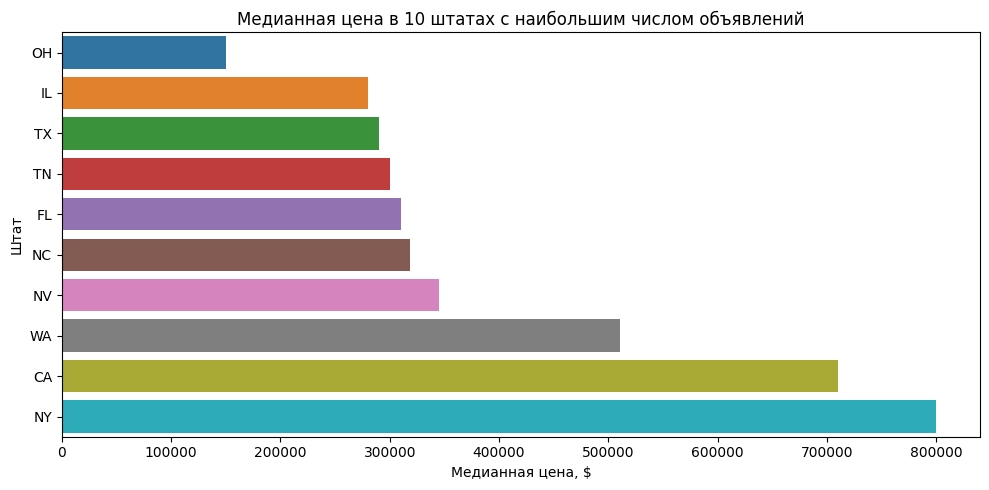

,listings,median_price
state,,
OH,11495,149900.0
IL,8179,279900.0
TX,77916,290000.0
TN,15832,299900.0
FL,101997,309900.0
NC,18886,319000.0
NV,7642,345000.0
WA,12526,510990.0
CA,22151,710000.0


In [111]:
state_stats = (
    sales_df.groupby('state')
    .agg(
        listings=('price', 'size'),
        median_price=('price', 'median')
    )
    .sort_values('listings', ascending=False)
    .head(10)
    .sort_values('median_price')
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=state_stats.reset_index(),
    x='median_price',
    y='state',
    hue='state',
    legend=False
)

plt.title('Медианная цена в 10 штатах с наибольшим числом объявлений')
plt.xlabel('Медианная цена, $')
plt.ylabel('Штат')
plt.tight_layout()
plt.show()

display(state_stats)

### Географические признаки

В выборке представлены 38 штатов, 1 908 городов и 4 469 ZIP-кодов. 
Признаки `state` и `zipcode` полностью заполнены, у `city` отсутствуют только 9 значений.

География является ключевым фактором стоимости недвижимости, поэтому все три признака будут включены в модель. Для оценки различий между регионами используется медианная цена, так как она устойчива к дорогим объектам в правом хвосте распределения.

In [113]:
import ast

def extract_fact(value, label):
    if pd.isna(value):
        return np.nan
    
    try:
        data = ast.literal_eval(value)
        for fact in data.get('atAGlanceFacts', []):
            if str(fact.get('factLabel', '')).strip().lower() == label.lower():
                result = fact.get('factValue')
                return np.nan if result in [None, '', 'None'] else result
    except (ValueError, SyntaxError, TypeError, AttributeError):
        return np.nan
    
    return np.nan

sales_df['year_built'] = pd.to_numeric(
    sales_df['homeFacts'].apply(lambda x: extract_fact(x, 'Year built')),
    errors='coerce'
)

invalid_year = (
    sales_df['year_built'].notna()
    & ~sales_df['year_built'].between(1600, 2026)
)

print('Некорректных годов:', invalid_year.sum())
sales_df.loc[invalid_year, 'year_built'] = np.nan

print('Доля пропусков, %:', round(sales_df['year_built'].isna().mean() * 100, 2))
print('Минимум:', sales_df['year_built'].min())
print('Медиана:', sales_df['year_built'].median())
print('Максимум:', sales_df['year_built'].max())

Некорректных годов: 6
Доля пропусков, %: 10.58
Минимум: 1703.0
Медиана: 1985.0
Максимум: 2025.0


In [114]:
CURRENT_YEAR = 2026

sales_df['year_built_missing'] = sales_df['year_built'].isna().astype('int8')
sales_df['home_age'] = CURRENT_YEAR - sales_df['year_built']

print(
    sales_df[['year_built', 'home_age', 'year_built_missing']]
    .describe()
)

          year_built       home_age  year_built_missing
count  306452.000000  306452.000000       342702.000000
mean     1979.660156      46.339844            0.105777
std        33.465282      33.465282            0.307552
min      1703.000000       1.000000            0.000000
25%      1957.000000      19.000000            0.000000
50%      1985.000000      41.000000            0.000000
75%      2007.000000      69.000000            0.000000
max      2025.000000     323.000000            1.000000


In [115]:
for col in ['private pool', 'PrivatePool', 'fireplace']:
    print(f'\n{col}')
    display(
        sales_df[col]
        .fillna('missing')
        .astype(str)
        .str.strip()
        .str.lower()
        .value_counts()
        .head(15)
    )


private pool


private pool
missing    338551
yes          4151
Name: count, dtype: int64


PrivatePool


PrivatePool
missing    303007
yes         39695
Name: count, dtype: int64


fireplace


fireplace
missing             241300
yes                  69573
1                    14515
2                     2425
not applicable        1990
fireplace              847
3                      562
living room            433
location               399
wood burning           311
gas/gas logs           300
fireplace yn           287
special features       279
1 fireplace            274
0                      270
Name: count, dtype: int64

In [116]:
pool_text = (
    sales_df['PrivatePool']
    .fillna(sales_df['private pool'])
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

sales_df['has_pool'] = pool_text.eq('yes').astype('int8')
sales_df['pool_missing'] = pool_text.eq('').astype('int8')

fireplace_text = (
    sales_df['fireplace']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

no_fireplace = {
    '', '0', 'no', 'none', 'nan',
    'not applicable', 'false'
}

sales_df['has_fireplace'] = (
    fireplace_text.ne('')
    & ~fireplace_text.isin(no_fireplace)
).astype('int8')

sales_df['fireplace_missing'] = fireplace_text.eq('').astype('int8')

for col in ['has_pool', 'pool_missing', 'has_fireplace', 'fireplace_missing']:
    print(col, sales_df[col].value_counts().to_dict())

has_pool {0: 298856, 1: 43846}
pool_missing {1: 298856, 0: 43846}
has_fireplace {0: 243825, 1: 98877}
fireplace_missing {1: 241300, 0: 101402}


,spearman_corr_with_log_price
log_price,1.000000
baths_num,0.556387
sqft_num,0.553723
beds_num,0.321317
stories_num,0.283715
home_age,-0.167621


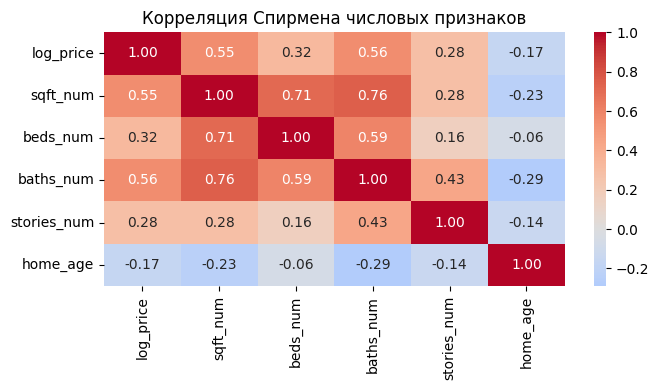

In [117]:
eda_numeric = sales_df[
    ['log_price', 'sqft_num', 'beds_num', 'baths_num', 'stories_num', 'home_age']
]

corr = eda_numeric.corr(method='spearman')['log_price'].sort_values(ascending=False)

display(corr.to_frame('spearman_corr_with_log_price'))

plt.figure(figsize=(7, 4))
sns.heatmap(
    eda_numeric.corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Корреляция Спирмена числовых признаков')
plt.tight_layout()
plt.show()

In [118]:
from scipy.stats import kruskal

groups = [
    sales_df.loc[
        sales_df['property_group'] == group,
        'log_price'
    ].dropna()
    for group in sales_df['property_group'].unique()
    if group != 'missing'
]

stat, p_value = kruskal(*groups)

print(f'Kruskal-Wallis H: {stat:.2f}')
print(f'p-value: {p_value:.3e}')

Kruskal-Wallis H: 8974.12
p-value: 0.000e+00


In [119]:
feature_cols = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'home_age',
    'year_built_missing',
    'has_pool',
    'has_fireplace',
    'fireplace_missing',
    'property_group',
    'state',
    'city',
    'zipcode'
]

feature_report = pd.DataFrame({
    'dtype': sales_df[feature_cols].dtypes.astype(str),
    'missing_pct': (sales_df[feature_cols].isna().mean() * 100).round(2),
    'unique': sales_df[feature_cols].nunique(dropna=True)
})

display(feature_report)

,dtype,missing_pct,unique
sqft_num,float64,7.61,9055
beds_num,float64,24.13,360
baths_num,float64,27.53,61
stories_num,float64,42.34,18
home_age,float64,10.58,219
year_built_missing,int8,0.00,2
has_pool,int8,0.00,2
has_fireplace,int8,0.00,2
fireplace_missing,int8,0.00,2
property_group,object,0.00,8


In [120]:
from sklearn.model_selection import train_test_split

X = sales_df[feature_cols].copy()
y = sales_df['log_price'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (274161, 13)
Test: (68541, 13)


In [122]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

baseline_log_pred = np.full(len(y_test), y_train.median())
baseline_price_pred = np.expm1(baseline_log_pred)
y_test_price = np.expm1(y_test)

baseline_mae = mean_absolute_error(y_test_price, baseline_price_pred)
baseline_rmse = root_mean_squared_error(y_test_price, baseline_price_pred)
baseline_r2 = r2_score(y_test_price, baseline_price_pred)

print(f'Baseline MAE: ${baseline_mae:,.0f}')
print(f'Baseline RMSE: ${baseline_rmse:,.0f}')
print(f'Baseline R²: {baseline_r2:.3f}')

Baseline MAE: $469,609
Baseline RMSE: $1,812,225
Baseline R²: -0.034


In [123]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge

numeric_features = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'home_age',
    'year_built_missing',
    'has_pool',
    'has_fireplace',
    'fireplace_missing'
]

categorical_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        min_frequency=20
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)

ridge_log_pred = ridge_model.predict(X_test)
ridge_price_pred = np.expm1(ridge_log_pred)

print(f'Ridge MAE: ${mean_absolute_error(y_test_price, ridge_price_pred):,.0f}')
print(f'Ridge RMSE: ${root_mean_squared_error(y_test_price, ridge_price_pred):,.0f}')
print(f'Ridge R²: {r2_score(y_test_price, ridge_price_pred):.3f}')

Ridge MAE: $312,479
Ridge RMSE: $1,879,365
Ridge R²: -0.112


In [124]:
print(f'Ridge log-MAE: {mean_absolute_error(y_test, ridge_log_pred):.3f}')
print(f'Ridge log-RMSE: {root_mean_squared_error(y_test, ridge_log_pred):.3f}')
print(f'Ridge log-R²: {r2_score(y_test, ridge_log_pred):.3f}')

Ridge log-MAE: 0.381
Ridge log-RMSE: 0.570
Ridge log-R²: 0.710


In [126]:
from catboost import CatBoostRegressor

cat_features = ['property_group', 'state', 'city', 'zipcode']

X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].fillna('missing').astype(str)
    X_test_cb[col] = X_test_cb[col].fillna('missing').astype(str)

cat_feature_indices = [
    X_train_cb.columns.get_loc(col)
    for col in cat_features
]

catboost_model = CatBoostRegressor(
    loss_function='RMSE',
    iterations=700,
    depth=8,
    learning_rate=0.08,
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices
)

cb_log_pred = catboost_model.predict(X_test_cb)
cb_price_pred = np.expm1(cb_log_pred)

print(f'CatBoost MAE: ${mean_absolute_error(y_test_price, cb_price_pred):,.0f}')
print(f'CatBoost RMSE: ${root_mean_squared_error(y_test_price, cb_price_pred):,.0f}')
print(f'CatBoost R²: {r2_score(y_test_price, cb_price_pred):.3f}')
print(f'CatBoost log-R²: {r2_score(y_test, cb_log_pred):.3f}')

0:	learn: 1.0131908	total: 1.15s	remaining: 13m 21s
100:	learn: 0.4879694	total: 32.9s	remaining: 3m 14s
200:	learn: 0.4606926	total: 1m 3s	remaining: 2m 37s
300:	learn: 0.4455696	total: 1m 33s	remaining: 2m 3s
400:	learn: 0.4367860	total: 2m 3s	remaining: 1m 32s
500:	learn: 0.4297638	total: 2m 35s	remaining: 1m 1s
600:	learn: 0.4243080	total: 3m 6s	remaining: 30.7s
699:	learn: 0.4195697	total: 3m 38s	remaining: 0us
CatBoost MAE: $209,242
CatBoost RMSE: $1,125,040
CatBoost R²: 0.602
CatBoost log-R²: 0.838


In [127]:
X_train_cb, X_valid_cb, y_train_cb, y_valid_cb = train_test_split(
    X_train_cb,
    y_train,
    test_size=0.15,
    random_state=RANDOM_STATE
)

catboost_valid = CatBoostRegressor(
    loss_function='RMSE',
    iterations=2000,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

catboost_valid.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cb, y_valid_cb),
    early_stopping_rounds=100,
    use_best_model=True
)

valid_log_pred = catboost_valid.predict(X_valid_cb)

print('Best iteration:', catboost_valid.get_best_iteration())
print(f'Validation log-R²: {r2_score(y_valid_cb, valid_log_pred):.3f}')
print(f'Validation log-RMSE: {root_mean_squared_error(y_valid_cb, valid_log_pred):.3f}')

0:	learn: 1.0283417	test: 1.0350013	best: 1.0350013 (0)	total: 633ms	remaining: 21m 5s
200:	learn: 0.4822622	test: 0.4747926	best: 0.4747926 (200)	total: 56.7s	remaining: 8m 27s
400:	learn: 0.4560228	test: 0.4525523	best: 0.4525523 (400)	total: 1m 54s	remaining: 7m 38s
600:	learn: 0.4423177	test: 0.4429455	best: 0.4429455 (600)	total: 2m 53s	remaining: 6m 44s
800:	learn: 0.4329101	test: 0.4370258	best: 0.4370258 (800)	total: 3m 51s	remaining: 5m 45s
1000:	learn: 0.4254675	test: 0.4325681	best: 0.4325681 (1000)	total: 4m 48s	remaining: 4m 47s
1200:	learn: 0.4194514	test: 0.4294146	best: 0.4294146 (1200)	total: 5m 43s	remaining: 3m 48s
1400:	learn: 0.4144848	test: 0.4270332	best: 0.4270332 (1400)	total: 6m 36s	remaining: 2m 49s
1600:	learn: 0.4103276	test: 0.4250475	best: 0.4250475 (1600)	total: 7m 32s	remaining: 1m 52s
1800:	learn: 0.4067715	test: 0.4233158	best: 0.4233158 (1800)	total: 8m 27s	remaining: 56s
1999:	learn: 0.4035398	test: 0.4220010	best: 0.4220010 (1999)	total: 9m 23s	rem

In [128]:
from sklearn.metrics import median_absolute_error

models_report = pd.DataFrame([
    {
        'model': 'Median baseline',
        'MAE_$': baseline_mae,
        'RMSE_$': baseline_rmse,
        'R2_$': baseline_r2
    },
    {
        'model': 'Ridge (log price)',
        'MAE_$': mean_absolute_error(y_test_price, ridge_price_pred),
        'RMSE_$': root_mean_squared_error(y_test_price, ridge_price_pred),
        'R2_$': r2_score(y_test_price, ridge_price_pred)
    },
    {
        'model': 'CatBoost (log price)',
        'MAE_$': mean_absolute_error(y_test_price, cb_price_pred),
        'RMSE_$': root_mean_squared_error(y_test_price, cb_price_pred),
        'R2_$': r2_score(y_test_price, cb_price_pred),
        'Median_AE_$': median_absolute_error(y_test_price, cb_price_pred),
        'log_R2': r2_score(y_test, cb_log_pred)
    }
])

display(models_report.round(3))

,model,MAE_$,RMSE_$,R2_$,Median_AE_$,log_R2
0,Median baseline,469609.260,1812225.058,-0.034,NaN,NaN
1,Ridge (log price),312479.203,1879365.228,-0.112,NaN,NaN
2,CatBoost (log price),209242.252,1125039.838,0.602,51146.689,0.838


In [129]:
test_results = X_test.copy()

test_results['actual_price'] = y_test_price
test_results['predicted_price'] = cb_price_pred
test_results['absolute_error'] = (
    test_results['actual_price'] - test_results['predicted_price']
).abs()

test_results['price_segment'] = pd.qcut(
    test_results['actual_price'],
    q=5,
    duplicates='drop'
)

error_by_segment = (
    test_results.groupby('price_segment', observed=True)
    .agg(
        listings=('actual_price', 'size'),
        median_actual_price=('actual_price', 'median'),
        mae=('absolute_error', 'mean'),
        median_ae=('absolute_error', 'median')
    )
)

display(error_by_segment.round(0))

,listings,median_actual_price,mae,median_ae
price_segment,,,,
"(999.999, 183491.0]",13709,120000.0,37673.0,25149.0
"(183491.0, 279900.0]",13753,233490.0,42190.0,28737.0
"(279900.0, 408451.0]",13663,338500.0,63376.0,44429.0
"(408451.0, 700000.0]",13728,519990.0,122675.0,81529.0
"(700000.0, 115000000.0]",13688,1225000.0,781340.0,294444.0


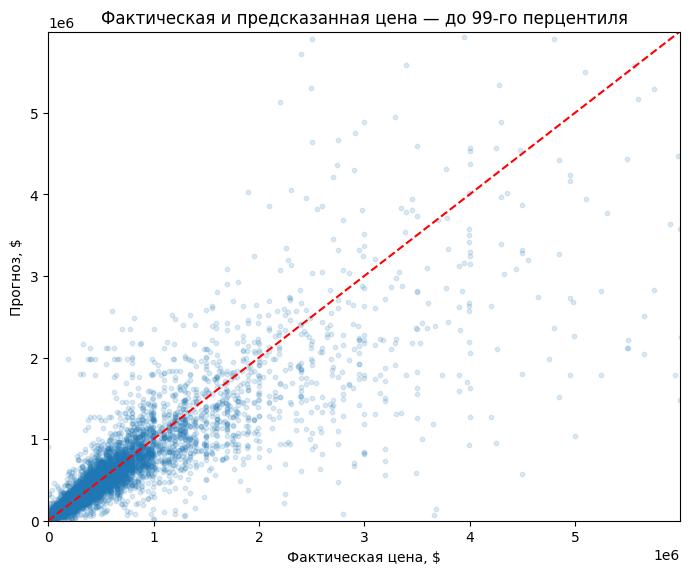

In [130]:
plot_df = test_results.sample(
    n=min(10_000, len(test_results)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(7, 6))
plt.scatter(
    plot_df['actual_price'],
    plot_df['predicted_price'],
    alpha=0.15,
    s=10
)

limit = plot_df[['actual_price', 'predicted_price']].quantile(0.99).max()

plt.plot([0, limit], [0, limit], color='red', linestyle='--')
plt.xlim(0, limit)
plt.ylim(0, limit)
plt.xlabel('Фактическая цена, $')
plt.ylabel('Прогноз, $')
plt.title('Фактическая и предсказанная цена — до 99-го перцентиля')
plt.tight_layout()
plt.show()

### Анализ ошибок CatBoost

Ошибка модели зависит от ценового сегмента. В первом квинтиле средняя абсолютная ошибка составляет 37.7 тыс. долларов, тогда как в верхнем квинтиле — 781.3 тыс. долларов.

Рост ошибки на дорогих объектах ожидаем: их цены имеют широкий разброс, а в данных представлены уникальные премиальные объекты. Медианная ошибка менее чувствительна к таким объектам и составляет 51.5 тыс. долларов по всей тестовой выборке.

Модель подходит для быстрой первичной оценки массового сегмента недвижимости. Для премиальных объектов сервис должен сопровождаться ручной экспертной проверкой.

In [132]:
X_train_cb_full = X_train.copy()
X_test_cb_full = X_test.copy()

for col in cat_features:
    X_train_cb_full[col] = X_train_cb_full[col].fillna('missing').astype(str)
    X_test_cb_full[col] = X_test_cb_full[col].fillna('missing').astype(str)

final_catboost = CatBoostRegressor(
    loss_function='RMSE',
    iterations=2000,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

final_catboost.fit(
    X_train_cb_full,
    y_train,
    cat_features=cat_feature_indices
)

final_log_pred = final_catboost.predict(X_test_cb_full)
final_price_pred = np.expm1(final_log_pred)

print(f'MAE_$: {mean_absolute_error(y_test_price, final_price_pred):,.0f}')
print(f'RMSE_$: {root_mean_squared_error(y_test_price, final_price_pred):,.0f}')
print(f'R2_$: {r2_score(y_test_price, final_price_pred):.3f}')
print(f'Median_AE_$: {median_absolute_error(y_test_price, final_price_pred):,.0f}')
print(f'log_R2: {r2_score(y_test, final_log_pred):.3f}')

0:	learn: 1.0299188	total: 584ms	remaining: 19m 26s
200:	learn: 0.4790222	total: 1m	remaining: 9m 4s
400:	learn: 0.4518086	total: 1m 59s	remaining: 7m 56s
600:	learn: 0.4375351	total: 2m 57s	remaining: 6m 54s
800:	learn: 0.4281048	total: 3m 57s	remaining: 5m 55s
1000:	learn: 0.4216768	total: 4m 58s	remaining: 4m 58s
1200:	learn: 0.4167254	total: 5m 59s	remaining: 3m 59s
1400:	learn: 0.4123404	total: 6m 58s	remaining: 2m 59s
1600:	learn: 0.4080614	total: 7m 58s	remaining: 1m 59s
1800:	learn: 0.4042204	total: 8m 57s	remaining: 59.4s
1999:	learn: 0.4009249	total: 9m 57s	remaining: 0us
MAE_$: 202,016
RMSE_$: 1,106,580
R2_$: 0.614
Median_AE_$: 48,959
log_R2: 0.846


### Финальная модель CatBoost

Финальная модель CatBoostRegressor обучена на полной обучающей выборке из 274 161 наблюдения. В качестве целевой переменной использовался логарифм цены `log_price = log1p(price)`. 

На отложенной тестовой выборке модель получила `R² = 0.846` для логарифма цены. Это означает, что модель хорошо улавливает относительные различия между стоимостью объектов.

После обратного преобразования прогнозов в доллары получены следующие метрики: MAE = 202 016 долларов, медианная абсолютная ошибка = 48 959 долларов, RMSE = 1 106 580 долларов и R² = 0.614.

Существенная разница между MAE и медианной ошибкой, а также высокое значение RMSE связаны с правосторонней асимметрией цен: небольшое число премиальных объектов имеет очень высокую цену и крупные абсолютные ошибки. Поэтому для массового сегмента наиболее показательна медианная абсолютная ошибка — около 49 тыс. долларов.

Модель подходит для первичной автоматизированной оценки недвижимости. Для дорогих и уникальных объектов прогноз следует использовать совместно с экспертной оценкой.

In [133]:
import joblib

final_catboost.save_model('catboost_real_estate.cbm')

artifact = {
    'feature_columns': X_train.columns.tolist(),
    'categorical_features': cat_features,
    'target_transform': 'log1p',
    'model_type': 'CatBoostRegressor'
}

joblib.dump(artifact, 'real_estate_model_metadata.joblib')

['real_estate_model_metadata.joblib']

In [136]:
import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostRegressor

model = CatBoostRegressor()
model.load_model('catboost_real_estate.cbm')

metadata = joblib.load('real_estate_model_metadata.joblib')

feature_columns = metadata['feature_columns']
categorical_features = metadata['categorical_features']

def predict_price(listing: dict) -> float:
    """
    Возвращает прогноз стоимости объекта в долларах.
    listing должен содержать все признаки, использованные при обучении.
    """
    row = pd.DataFrame([listing])

    missing_features = set(feature_columns) - set(row.columns)
    if missing_features:
        raise ValueError(
            'Не переданы обязательные признаки: '
            + ', '.join(sorted(missing_features))
        )

    row = row.reindex(columns=feature_columns)

    for col in categorical_features:
        row[col] = row[col].fillna('missing').astype(str)

    log_prediction = model.predict(row)[0]
    return float(np.expm1(log_prediction))

In [137]:
example_listing = X_test.iloc[0].to_dict()

predicted_price = predict_price(example_listing)
actual_price = y_test_price.iloc[0]

print(f'Фактическая цена: ${actual_price:,.0f}')
print(f'Прогноз модели:  ${predicted_price:,.0f}')
print(f'Абсолютная ошибка: ${abs(actual_price - predicted_price):,.0f}')

Фактическая цена: $308,990
Прогноз модели:  $300,204
Абсолютная ошибка: $8,786


### Сохранение и применение модели

Финальная модель сохранена в формате CatBoost (`catboost_real_estate.cbm`). Отдельно сохранены метаданные: перечень 13 признаков, список категориальных признаков и описание преобразования целевой переменной.

Для получения прогноза сервис принимает признаки объекта, формирует таблицу в том же порядке, что при обучении, обрабатывает категориальные поля и передаёт данные модели. Так как модель обучалась предсказывать `log1p(price)`, итоговый прогноз восстанавливается в исходной шкале с помощью `expm1()`.

Такой подход позволяет использовать обученную модель повторно без её переобучения и снижает риск ошибки из-за другого порядка или состава признаков.

## Итоговый вывод

В проекте разработана модель CatBoostRegressor для первичной оценки стоимости объектов недвижимости.

Модель обучалась предсказывать логарифм цены, что уменьшило влияние редких очень дорогих объектов и позволило точнее описывать относительные различия в стоимости. На отложенной тестовой выборке достигнуты следующие результаты:

- MAE: 202 016 долларов;
- медианная абсолютная ошибка: 48 959 долларов;
- RMSE: 1 106 580 долларов;
- R² в исходной шкале цены: 0.614;
- R² для логарифма цены: 0.846.

Модель демонстрирует наилучшее качество в массовом ценовом сегменте. Ошибка растёт для дорогих и уникальных объектов, поэтому её прогноз следует рассматривать как первичную автоматизированную оценку. Для премиальной недвижимости рекомендуется дополнительная экспертная проверка.

Финальная модель и метаданные сохранены отдельно, а функция `predict_price()` позволяет получать прогнозы для новых объектов без повторного обучения.